### 지도학습 절차

- 지도학습 : 목표변수(Y)와 설명변수(X)의 관계를 학습해서, 새로운 X가 들어올 때, Y를 예측 / 분류

- 지도학습의 절차 6단계:
  1. 데이터 핸들링 (데이터 불러오기 / 파생변수 생성 / 층별화) : 데이터 구조적인 관점에서 학습을 수행할 수 있는 데이터셋을 구성하는 과정

  2. 학습에 사용될 목표변수(Y)와 설명변수(X)를 설정
    - 유의사항 : 사용되는 X는 새로 들어올 데이터에 대한 값으로 지정 ex. 신규고객 이탈 예측을 할 때 구매횟수와 방문횟수를 넣으면 안 됨.

  3. 학습 데이터(Train Set)와 검증 데이터(Test Set)분할
    - 검증 데이터(Test Set)는 학습에 참여하지 않는다! (교차검증에서 Validation Set과는 다른 개념)

  4. 학습을 수행 (Modeling)
    - 특성공학 (결측값 처리 / Encoding / Scaling ...) -> Pipe Line을 이용해서
    - 학습 (알고리즘)

  5. 학습된 모델 평가
    - 학습 능력 평가
    - 일반화 능력 평가


In [1]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

- 사용한 데이터 (https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [2]:
# 데이터 불러오기
df1 = pd.read_csv('diabetes.csv')
print(df1.shape)
print(df1.info())
print(df1.head())
print(df1.tail())

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2         

In [3]:
# 환자의 건강 관련 정보를 입력했을 때, 당뇨병에 걸릴지 말지에 대한 판별 모델 생성
# 1) 데이터 핸들링
df1['Outcome'].unique()

array([1, 0])

## **당뇨병(outcome)**
당뇨병 : 혈액 속 포도당 수치가 높게 유지되는 질환

  1. 1형 당뇨병 : 인슐린이 거의 또는 전혀 분비되지 않는 경우
  - 주로 소아,청소년기에 발생
  2. 2형 당뇨병 : 인슐린은 분비되지만 세포가 인슐린에 제대로 반응 x
  - 성인에게 주로 발생
  - 비만, 생활습관, 유전적 요인과 밀접한 관련 

-------------------------------------------------------------------
Insulin과 당뇨병   [인슐린 : 혈당을 낮추는 역할 ]
- 인슐린 저항성이 증가 = 인슐린 분비 O -> 작용 X -> 혈당 상승 
- 과정 ( BMI 증가 -> 체지방 증가 -> 인슐린 저항성 증가 -> 혈당 상승 -> 당뇨병 위험 증가 )

-------------------------------------------------------------------
BMI,SkinThickness와 당뇨병
- BMI가 높을수록 :
- 지방 조직에서 인슐린 작용을 방해하는 물질 분비 증가 -> 인슐린 저항성 증가 
- 2형 당뇨 위험 ↑

- SkinThickness는 체지방 분포를 간접적으로 반영 

-------------------------------------------------------------------
Pregnancies와 당뇨병
- 임신 시 : 태아 성장을 위한 호르몬 증가 -> 인슐린 저항성 증가 
- 임신을 많이 경험한 여성 : 임신성 당뇨 경험 가능성 증가  => 2형 당뇨 위험 ↑

-------------------------------------------------------------------
Age와 당뇨병
- 나이가 많을수록 -> 인슐린 감수성 감소
- 같은 BMI라도 고령일수록 => 당뇨 위험 ↑

-------------------------------------------------------------------
DPF와 당뇨병
- 값이 높을수록 => 유전적 당뇨병 위험 ↑

## **결측치는 없지만 0이 나올 수 있는 변수와 아닌 변수를 구분해서 EDA 할 것**

In [4]:
df1.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

- 결측치 확인 -> 없음 

그러나 도메인 지식을 고려할 때 결측치가 0으로 대체되어 저장된 것으로 판단 

## **Pregrance**
 - 임신횟수
 - 0 가능

In [5]:
df1["Pregnancies"].value_counts()

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: count, dtype: int64

In [6]:
#임신 횟수가 주어졌을 떄 당뇨일 확률 
# P(outcome =1 | Pregnancies)
prob = (df1.groupby("Pregnancies")["Outcome"].mean())
prob

Pregnancies
0     0.342342
1     0.214815
2     0.184466
3     0.360000
4     0.338235
5     0.368421
6     0.320000
7     0.555556
8     0.578947
9     0.642857
10    0.416667
11    0.636364
12    0.444444
13    0.500000
14    1.000000
15    1.000000
17    1.000000
Name: Outcome, dtype: float64

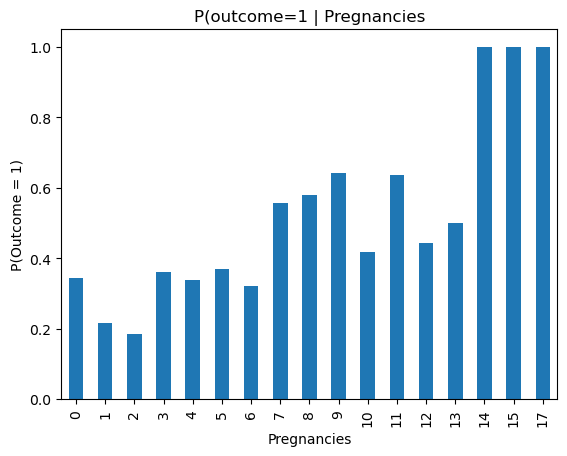

In [7]:
prob.plot(kind="bar")
plt.xlabel("Pregnancies")
plt.ylabel("P(Outcome = 1)")
plt.title("P(outcome=1 | Pregnancies")
plt.show()

<Axes: title={'center': 'Pregnancies'}, xlabel='Pregnancies'>

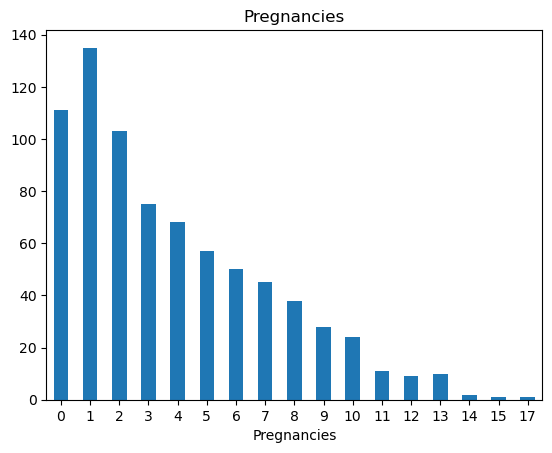

In [8]:
df1["Pregnancies"].value_counts().sort_index().plot(kind="bar", rot=0, title="Pregnancies")

### **변수 인사이트 정리**

1. Pregnancies 변수는 횟수가 증가할수록 전반적으로 내림차순으로 정렬됨을 알 수 있음
2. 임신 횟수가 많을수록 당뇨 확률이 증가하는 경향이 있음\
   특히 7회 이상부터 매우 높아짐 

## **glucose**
- 혈장 포도당 농도
- 0 불가능
- 당뇨는 혈당이 지속적으로 높은 증상

In [9]:
# 셀 추가해서 EDA 하기

<Axes: ylabel='Glucose'>

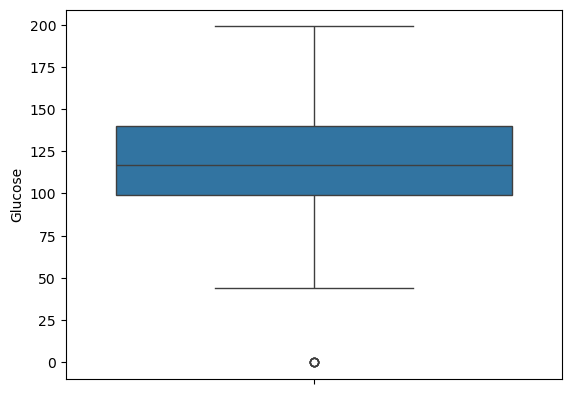

In [10]:
sns.boxplot(df1["Glucose"])

In [11]:
#0이 불가능하므로 결측치를 다른 값으로 채워야함 
df1["Glucose"].describe()

count    768.000000
mean     120.894531
std       31.972618
min        0.000000
25%       99.000000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

In [12]:
zero_count = (df1["Glucose"] == 0).sum()
print(zero_count)

5


- 0(결측치)의 수가 매우 작으므로 결측치를 중앙값으로 대체하는것도 좋을 것 같음

In [13]:
#0을 NA로 변환
df1["Glucose"] = df1["Glucose"].replace(0, np.nan)
df1["Glucose"].isna().sum()

np.int64(5)

In [14]:
# 중앙값으로 대체
glucose_median = df1["Glucose"].median()
df1["Glucose"] = df1["Glucose"].fillna(glucose_median)

<Axes: xlabel='Outcome', ylabel='Glucose'>

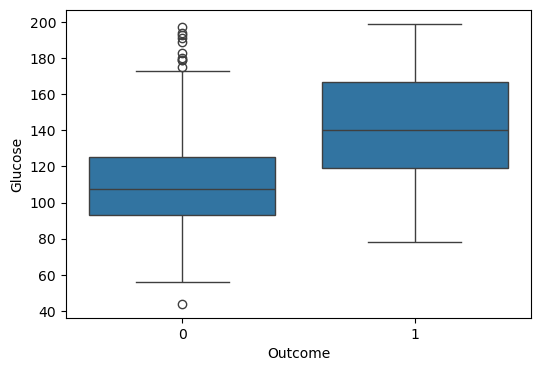

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df1, x="Outcome", y="Glucose")

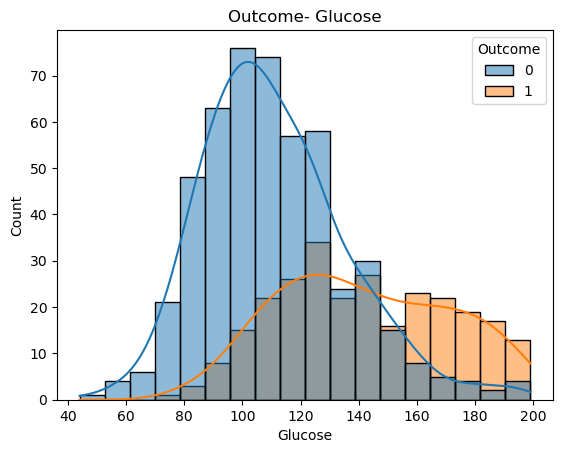

In [16]:
sns.histplot(data=df1, x="Glucose", hue="Outcome", kde=True)
plt.title("Outcome- Glucose")
plt.show()

### **변수 인사이트 정리**

- Glucose 변수에 0(결측치) 값이 5개로 매우 작음 
- 0을 NA로 변환 후 중앙값으로 대체
- Glucose값이 당뇨병이 발병한 사람 분포에서 더 높음을 확인 

## **bloodpressure**
- 혈압
- 0 불가능
- 이완기 혈압으로 기록

| 혈압 분류          | 이완기 혈압 기준 (mmHg) |
| -------------- | ---------------- |
| **정상**         | < 80             |
| **고혈압 전단계**    | 80 ~ 89          |
| **고혈압(1기 이상)** | ≥ 90             |



In [17]:
# 셀 추가해서 EDA 하기 #0인거 전처리

In [18]:
df1["BloodPressure"].describe()

count    768.000000
mean      69.105469
std       19.355807
min        0.000000
25%       62.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

<Axes: ylabel='BloodPressure'>

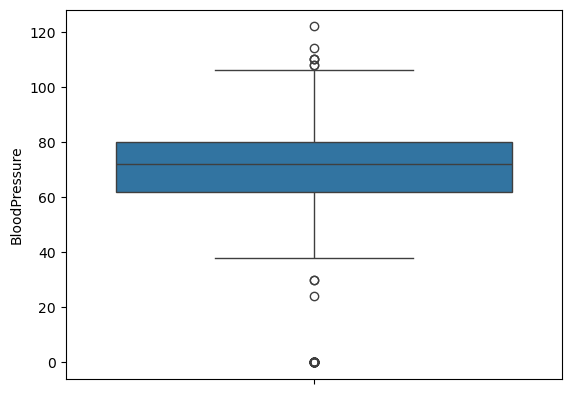

In [19]:
#boxplot으로 결측치 확인 
sns.boxplot(df1["BloodPressure"])

In [20]:
zero_count = (df1["BloodPressure"] == 0).sum()
print(zero_count) #0 개수 : 35

35


In [21]:
total_count = len(df1)
zero_ratio = zero_count / total_count
print(zero_ratio*100) #0이 전체의 4.5% 차지 

4.557291666666666


- 0(결측치)의 수가 매우 작으므로 결측치를 중앙값으로 대체하는것도 좋을 것 같음

In [22]:
#0을 NA로 변환
df1["BloodPressure"] = df1["BloodPressure"].replace(0, np.nan)
df1["BloodPressure"].isna().sum()

np.int64(35)

In [23]:
# 중앙값으로 대체
bp_median = df1["BloodPressure"].median()
df1["BloodPressure"] = df1["BloodPressure"].fillna(bp_median)

<Axes: ylabel='BloodPressure'>

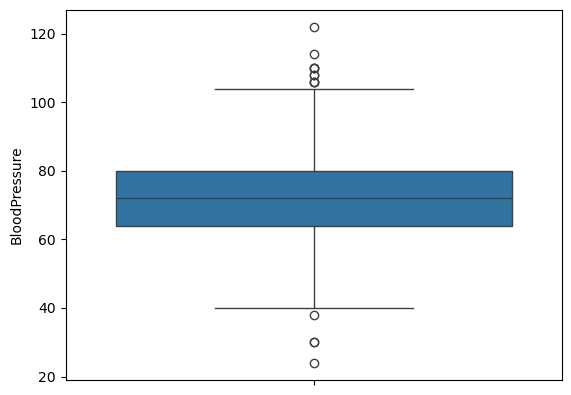

In [24]:
sns.boxplot(df1["BloodPressure"]) #0 사라진거 확인 

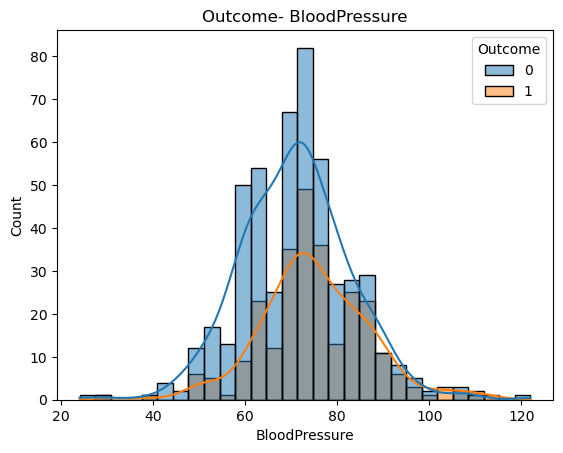

In [25]:
#시각화
sns.histplot(data=df1, x="BloodPressure", hue="Outcome", kde=True)
plt.title("Outcome- BloodPressure")
plt.show()

In [26]:
#혈압 범주 함수 정의
def bp_category(diastolic):
    if diastolic < 80:
        return "정상   "
    elif diastolic < 90:
        return "고혈압 전"
    else:
        return "고혈압  "

In [27]:
df1["BP_category"] = df1["BloodPressure"].apply(bp_category)

In [28]:
bp_outcome_table = df1.pivot_table(
    index="BP_category",
    columns="Outcome",
    values="BloodPressure",
    aggfunc="count"
)

In [29]:
bp_outcome_table.columns = ["Outcome=0 (비당뇨)", "Outcome=1 (당뇨)"]

In [30]:
bp_outcome_table["Total"] = bp_outcome_table.sum(axis=1)
bp_outcome_table["당뇨 비율 (%)"] = bp_outcome_table["Outcome=1 (당뇨)"] / bp_outcome_table["Total"] * 100

In [31]:
print(bp_outcome_table)

             Outcome=0 (비당뇨)  Outcome=1 (당뇨)  Total  당뇨 비율 (%)
BP_category                                                   
고혈압                       31              29     60  48.333333
고혈압 전                     84              61    145  42.068966
정상                       385             178    563  31.616341


### **변수 인사이트 정리**

- Glucose변수와 동일하게 결측치 제거
- 고혈압이 있는 사람은 일반인보다 인슐린 저항성이 더 흔하고 당뇨 발생 위험이 증가하는 경향이 있다는 연구 결과가 있음 => 서로 관련
- https://pubmed.ncbi.nlm.nih.gov/29459239/
- BP 카테고리로 나누어 당뇨가 있는 사람의 비율을 확인해 보았을 때 48.33%로 가장 높음을 확인하였음 

## **BMI**
- 0 불가능
- BMI ↑ -> 인슐린 저항성 ↑ -> 2형 당뇨 위험 ↑

| 범위          | 분류  |             |
| ----------- | --- | ----------- |
| < 18.5      | 저체중 |             |
| 18.5 ~ 24.9 | 정상  |             |
| 25.0 ~ 29.9 | 과체중 |             |
| ≥ 30        | 비만  |               |


In [32]:
# 셀 추가해서 EDA 하기 

### **변수 인사이트 정리**

In [33]:
df1["BMI"].describe()

count    768.000000
mean      31.992578
std        7.884160
min        0.000000
25%       27.300000
50%       32.000000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

<Axes: ylabel='BMI'>

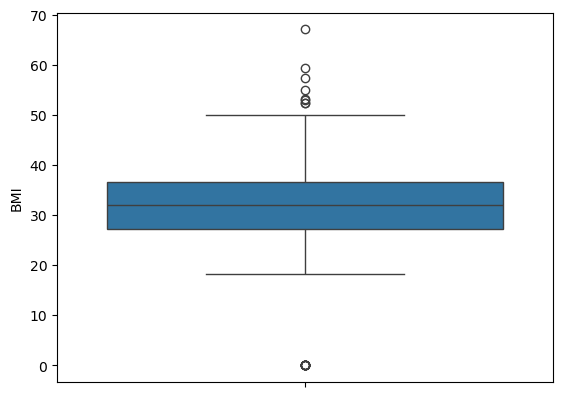

In [34]:
sns.boxplot(df1["BMI"])

In [35]:
zero_count = (df1["BMI"] == 0).sum()
print(zero_count) #0 개수 : 11

11


In [36]:
#0을 NA로 변환
df1["BMI"] = df1["BMI"].replace(0, np.nan)
df1["BMI"].isna().sum()

np.int64(11)

In [37]:
# 중앙값으로 대체
bp_median = df1["BMI"].median()
df1["BMI"] = df1["BMI"].fillna(bp_median)

<Axes: ylabel='BMI'>

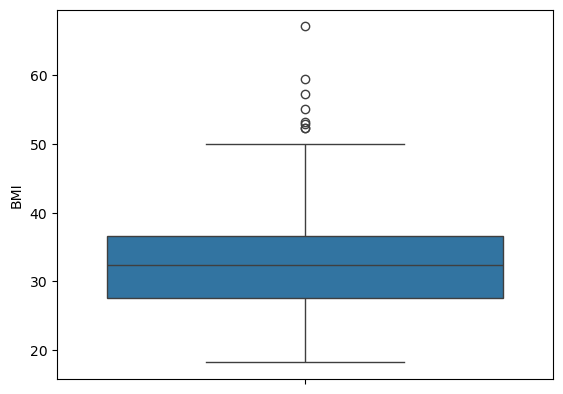

In [38]:
sns.boxplot(df1["BMI"]) #0 사라진거 확인 

In [39]:
df1.groupby('Outcome')['BMI'].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,30.885600,6.504128,18.2,25.75,30.40,35.300,57.3
1,268.0,35.383582,6.595603,22.9,30.90,34.25,38.775,67.1


In [40]:
df1.groupby("Outcome")["BMI"].mean() #당뇨그룹이 BMI가 더 높음 

Outcome
0    30.885600
1    35.383582
Name: BMI, dtype: float64

<Axes: xlabel='Outcome', ylabel='BMI'>

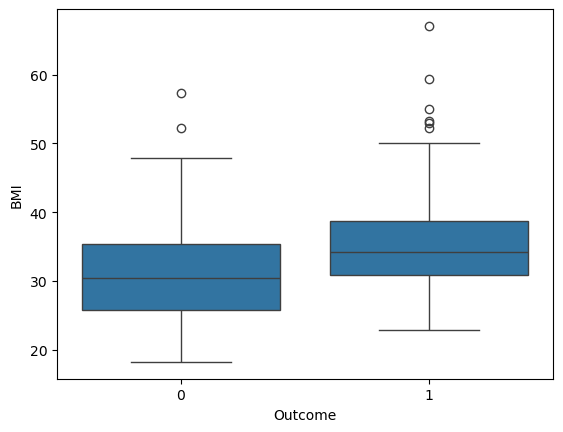

In [41]:
sns.boxplot(x="Outcome", y="BMI", data=df1) #시각화해서 확인 

In [42]:
#BMI 구간 설정
bins = [0, 18.5, 25, 30, np.inf]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

In [43]:
df1['BMI_group'] = pd.cut(df1['BMI'], bins=bins, labels=labels)

In [44]:
# BMI 그룹별 Outcome 비율 계산
bmi_table = pd.crosstab(df1['BMI_group'], df1['Outcome'], normalize='index')

print(bmi_table)

Outcome             0         1
BMI_group                      
Underweight  1.000000  0.000000
Normal       0.935185  0.064815
Overweight   0.755556  0.244444
Obese        0.544118  0.455882


<Axes: xlabel='BMI_group', ylabel='Outcome'>

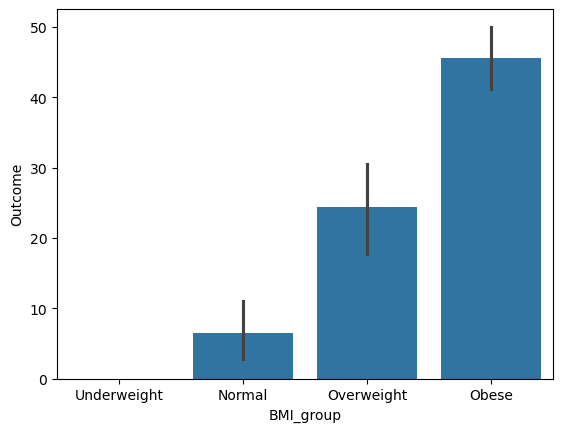

In [45]:
sns.barplot(x='BMI_group', y='Outcome', data=df1, estimator=lambda x: sum(x==1)/len(x)*100)
# 시각화

### **변수 인사이트 정리**


- 동일하게 결측치 변환 후 대체
- 당뇨병 환자의 BMI가 정상인에 비해 높음
- BMI 카테고리로 나누어 당뇨가 있는 사람의 비율을 확인해 보았을 때 obese 가장 높음을 확인
- underweight에서 obese로 갈수록 비율이 증가함을 확인 

## **SkinThickness**
- 삼두근 피부 두께
- 체지방이랑 관련이 있다.
- 0 불가능

In [46]:
# 셀 추가해서 EDA 하기

In [47]:
df1["SkinThickness"].describe()

count    768.000000
mean      20.536458
std       15.952218
min        0.000000
25%        0.000000
50%       23.000000
75%       32.000000
max       99.000000
Name: SkinThickness, dtype: float64

<Axes: ylabel='SkinThickness'>

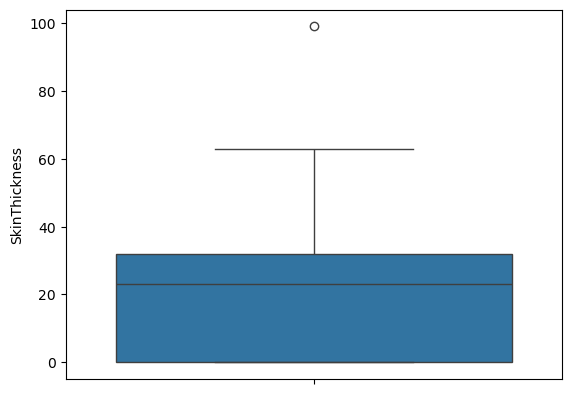

In [48]:
sns.boxplot(df1["SkinThickness"]) #0 있음 

In [49]:
zero_count = (df1["SkinThickness"] == 0).sum()
print(zero_count) #0 개수 : 227로 꽤 많음

227


In [50]:
# 숫자형 컬럼만 선택
num_cols = df1.select_dtypes(include='number')

In [51]:
# SkinThickness에서 0이 아닌 행으로
#상관관계 구하기 
num_nozero_st = num_cols[df1["SkinThickness"] != 0]
corr_with_skin = num_nozero_st.corr()["SkinThickness"].sort_values()

print(corr_with_skin)

Pregnancies                 0.100239
DiabetesPedigreeFunction    0.115016
Insulin                     0.126423
Age                         0.166816
BloodPressure               0.226723
Glucose                     0.227301
Outcome                     0.259491
BMI                         0.647978
SkinThickness               1.000000
Name: SkinThickness, dtype: float64


BMI가 0.6479로 높은 상관관계를 가짐 
-> 결측치를 bmi로 해결 ?

In [52]:
#0을 NA로 변환
df1["SkinThickness"] = df1["SkinThickness"].replace(0, np.nan)

In [53]:
# BMI 그룹별 SkinThickness의 중앙값 계산
bins = [0, 18.5, 25, 30, np.inf]
labels = ['Underweight','Normal','Overweight','Obese']
df1['BMI_group'] = pd.cut(df1['BMI'], bins=bins, labels=labels)

median_skin = df1.groupby('BMI_group', observed=True)["SkinThickness"].median()

In [54]:
# SkinThickness 결측치를 그 그룹 중앙값으로 채우기
df1['SkinThickness'] = df1.apply(
    lambda row: median_skin[row['BMI_group']] if pd.isna(row['SkinThickness']) else row['SkinThickness'],
    axis=1)

count    768.000000
mean      28.467448
std        9.475226
min        7.000000
25%       22.000000
50%       30.000000
75%       32.000000
max       99.000000
Name: SkinThickness, dtype: float64

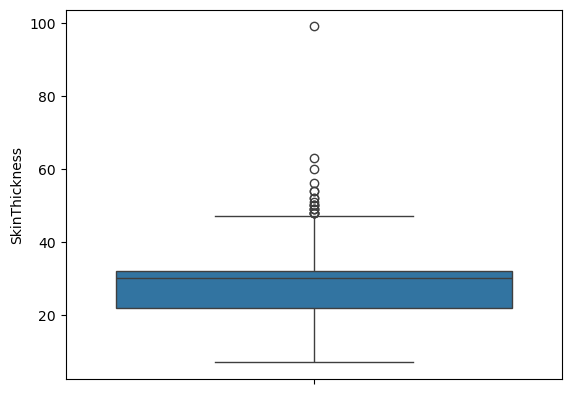

In [55]:
sns.boxplot(df1["SkinThickness"]) #0 제거 확인
df1["SkinThickness"].describe() 

### **변수 인사이트 정리**


- skinthickness는 bmi와 밀접한 관련이 있음 
- skinthickness의 결측치가 227로 꽤 많기 때문에 bmi를 활용해 채우는 것이 좋다고 판단 
- bmi의 카테고리로 나누어 결측치 채움 

## **Insulin**
- 인슐린 분비량
- 당뇨병 유형은 인슐린이 선천적으로 나오지 않는 사람(1형)과 인슐린이 나오지만 인식을 못하는 사람(2형) 당뇨병 두가지가 있다.
- 0 불가

In [56]:
# 셀 추가해서  EDA 하기 

In [57]:
df1["Insulin"].describe()

count    768.000000
mean      79.799479
std      115.244002
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64

<Axes: ylabel='Insulin'>

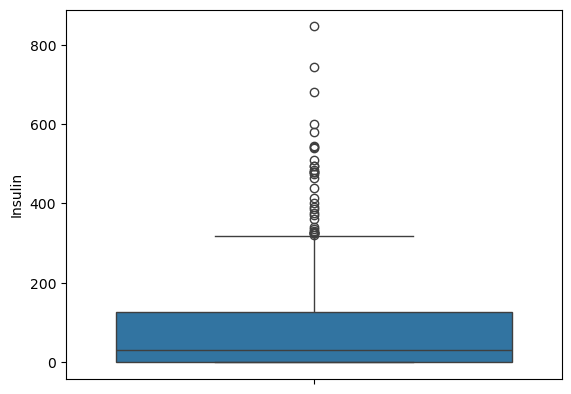

In [58]:
sns.boxplot(df1["Insulin"]) #0 있음 

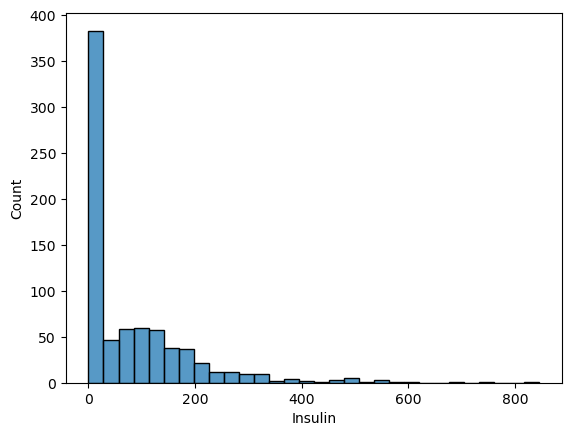

In [59]:
sns.histplot(df1["Insulin"],bins=30)
plt.show()

In [60]:
zero_count = (df1["Insulin"] == 0).sum()
print(zero_count)

374


In [61]:
#0을 NA로 변환
df1["Insulin"] = df1["Insulin"].replace(0, np.nan)

<Axes: ylabel='Insulin'>

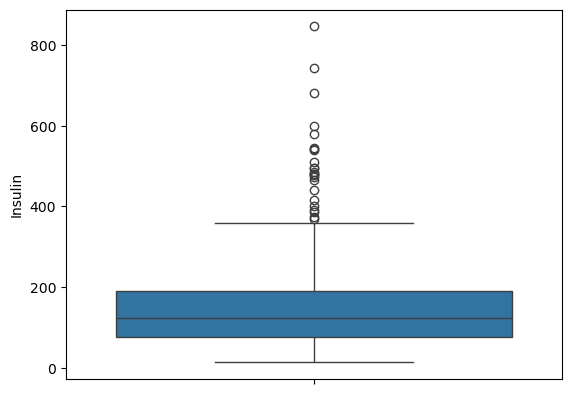

In [62]:
sns.boxplot(df1["Insulin"]) #이상치가 너무 많음 => median(이상치에 덜 민감)으로 대체 

In [63]:
# 중앙값으로 대체
bp_median = df1["Insulin"].median()
df1["Insulin"] = df1["Insulin"].fillna(bp_median)

<Axes: xlabel='BMI_group', ylabel='Insulin'>

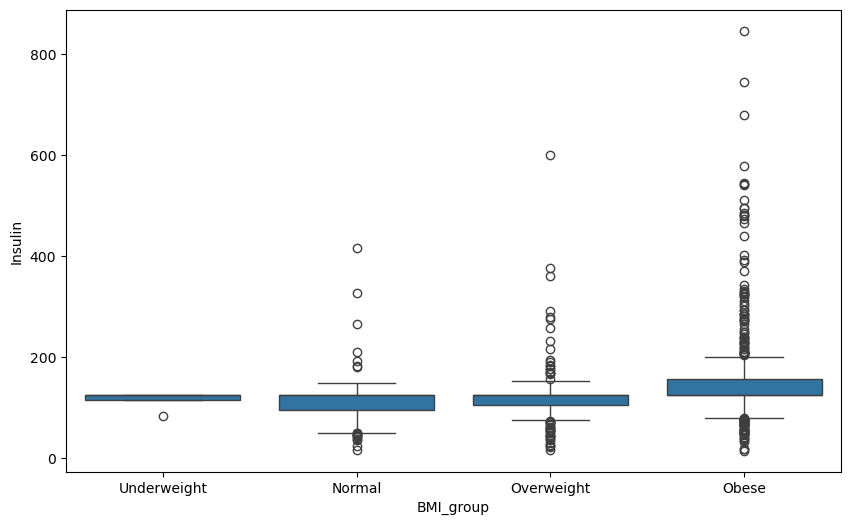

In [64]:
# BMI 증가 -> 체지방 증가 -> 인슐린 저항성 증가 
plt.figure(figsize=(10,6))
sns.boxplot(x='BMI_group', y='Insulin', data=df1)

<Axes: xlabel='Outcome', ylabel='Insulin'>

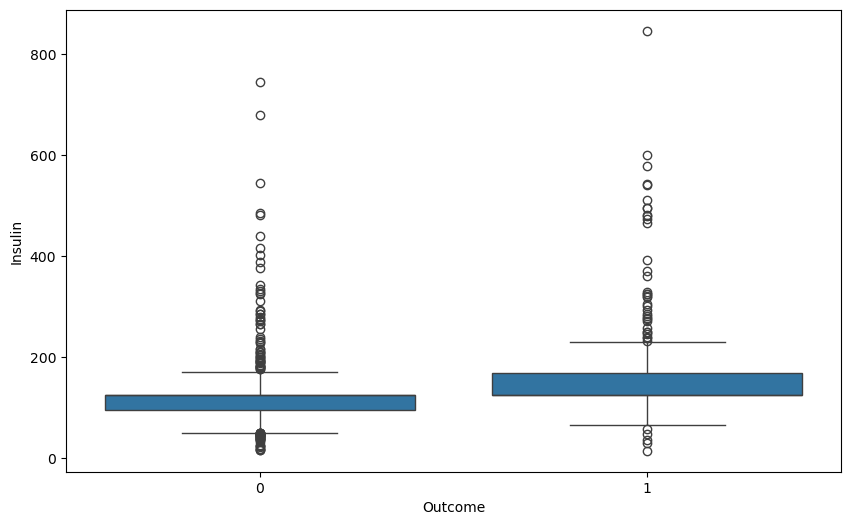

In [65]:
# 인슐린 저항성 증가 -> 혈당 상승 -> 당뇨병 위험 증가
plt.figure(figsize=(10,6))
sns.boxplot(x='Outcome', y='Insulin', data=df1)

### **변수 인사이트 정리**

- insulin의 0(결측치)가 374로 너무 많음
- boxplot 확인 결과 이상치가 너무 많으므로 median으로 대체
- bmi가 높을수록 insulin이 높음을 확인
- 당뇨병인 사람의 insulin분포가 정상인의 분포보다 더 높음을 확인
 
  => 따라서 bmi와 insulin과 당뇨병은 높은 연관성을 지님 

## **파생변수 생성 및 추가 전처리**

## **DPF(가족력)**
- 0 가능 

In [66]:
df1["DiabetesPedigreeFunction"].describe() 

count    768.000000
mean       0.471876
std        0.331329
min        0.078000
25%        0.243750
50%        0.372500
75%        0.626250
max        2.420000
Name: DiabetesPedigreeFunction, dtype: float64

In [67]:
df1.groupby("Outcome")["DiabetesPedigreeFunction"].mean()

Outcome
0    0.429734
1    0.550500
Name: DiabetesPedigreeFunction, dtype: float64

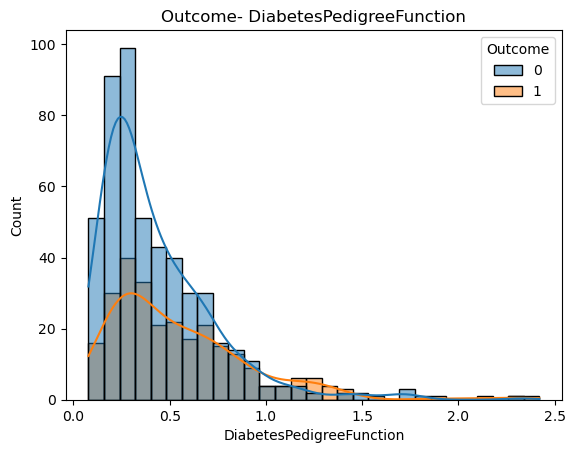

In [68]:
#시각화
sns.histplot(data=df1, x="DiabetesPedigreeFunction", hue="Outcome", kde=True)
plt.title("Outcome- DiabetesPedigreeFunction")
plt.show()

## **Age**
- 0 가능 

In [69]:
df1["Age"].describe()  

count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64

<Axes: ylabel='Age'>

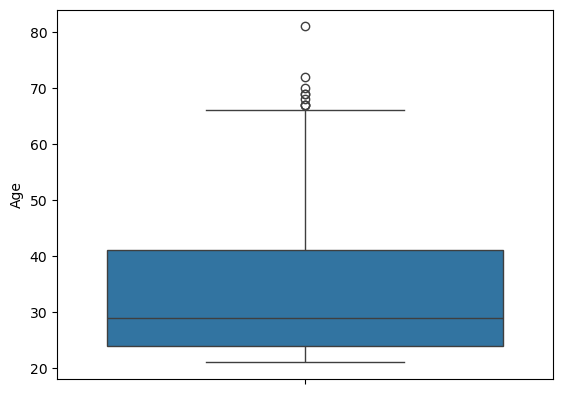

In [70]:
sns.boxplot(df1["Age"]) 

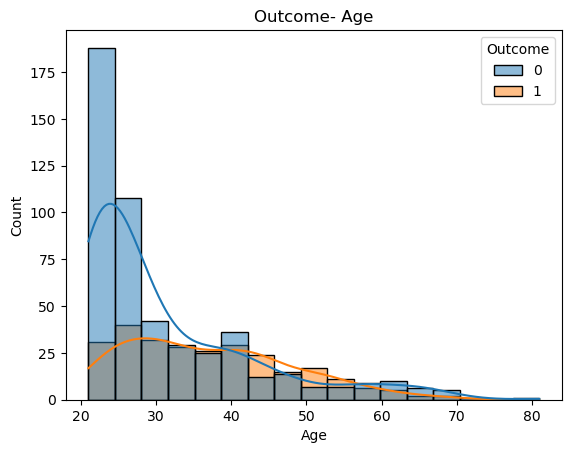

In [71]:
#시각화
sns.histplot(data=df1, x="Age", hue="Outcome", kde=True)
plt.title("Outcome- Age")
plt.show()

# **모델링하기**

In [72]:
# 2) 목표변수 / 설명변수 설정
# 파생 변수는 추가하고, 필요 없는 변수는 빼기

X = df1[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
Y = df1['Outcome'] # Y값에는 결측치가 존재해서는 안됨

In [73]:
# 3) 학습데이터와 검증데이터를 분할
# pip install scikit-learn
from sklearn.model_selection import train_test_split

In [74]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=1234, stratify=Y
) # X 데이터의 학습, 검증 데이터 & Y 데이터의 학습, 검증데이터 4개로 분리됨
#train과 test로 split(나누기) #test size는 25% 검증용 75% 학습용 
#random_state 결과 재현성 유지 #stratify=Y : outcome 비율을 유지하며 분리

In [75]:
X.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

=> X에도 결측치가 없는 데이터이지만, 추후 새로 들어올 데이터에 결측치가 존재할 수 있음

# **각자 공부한 모델 쓰기**

1. LogisticRegression란?
   - 로지스틱 회귀는 이진 분류 문제를 해결하는 대표적 모델
   
   -> 0/1 같은 두 개의 클래스를 구분하는데 적합

    -> 클래스에 속할 확률을 예측하고, 확률이 0.5 이상이면 1로, 아니면 0으로 예측
   - 선형 회귀와 달리 출력값은 확률(0 ~ 1)로 제한
  
    -> 시그모이드 함수를 사용해 선형 결합 결과를 0~1 범위로 변환
2. LogisticRegression 모델의 특징
   - 이진/다중 분류로 사용 가능
   - 확률 기반 예측 → .predict_proba()로 각 클래스의 확률 확인 가능
   - 선형 결정 경계(linear decision boundary) 기반
3. 중요한 하이퍼파라미터

| 하이퍼파라미터        | 설명                                                                       |
| -------------- | ------------------------------------------------------------------------ |
| `penalty`      | **정규화 규제** 종류 (`'l1'`, `'l2'`, `'elasticnet'`, `'none'`)                 |
| `C`            | **규제 강도 조절** 값 (작을수록 규제 강함, 과소적합 위험)                                     |
| `solver`       | 최적화 알고리즘 선택 (`'lbfgs'`, `'liblinear'`, `'sag'`, `'saga'`, `'newton-cg'`) |
| `max_iter`     | **수렴 반복 횟수** 최대값 (학습이 끝날 때까지 반복 허용 수)                                    |
| `random_state` | 랜덤 시드 설정 (결과 재현용)                                                        |


- 규제(penalty)는 복잡한 모델을 억제해서 과적합 방지하는 역할
- C는 그 규제의 강도를 조절하는 값

                                      from gpt..

Logistic Regression은 특히 **특성 값의 스케일(크기)**에 영향을 받을 수 있으므로, 전처리 시행 
- 결측치 처리
- 표준화(scaling) : 특성값 차이가 클 때 StandardScaler 같은 것으로 정규화 

In [76]:
#표준화 - scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- 로지스틱 회귀는 변수 스케일(단위)이 다르면 성능에 영향
- StandardScaler()는 각 특성을 평균 0, 표준편차 1로 바꿈
- 스케일링은 특히 Glucose, Insulin처럼 값 범위 차이가 큰 변수가 있을 때 중요

In [77]:
# 4) 학습 수행
from sklearn.linear_model import LogisticRegression

In [78]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, Y_train)# 학습 수행

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [79]:
# 5) 성능 확인
from sklearn.metrics import accuracy_score
# 정확도 : 전체 데이터 중 얼만큼 정확히 분류했는지 비율

In [95]:
Y_train_pred = model.predict(X_train_scaled)
Y_test_pred  = model.predict(X_test_scaled)

성능평가

In [96]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [97]:
print(classification_report(Y_train, Y_train_pred))
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       375
           1       0.72      0.57      0.63       201

    accuracy                           0.77       576
   macro avg       0.75      0.72      0.73       576
weighted avg       0.77      0.77      0.76       576

              precision    recall  f1-score   support

           0       0.81      0.88      0.85       125
           1       0.74      0.63      0.68        67

    accuracy                           0.79       192
   macro avg       0.78      0.75      0.76       192
weighted avg       0.79      0.79      0.79       192



In [83]:
#정확도 계
print("학습 정확도:", accuracy_score(Y_train, Y_train_pred)) # 여러 알고리즘에 대한 모델을 비교할 때 확인해야 함
print("검증 정확도:", accuracy_score(Y_test, Y_test_pred))

학습 정확도: 0.7708333333333334
검증 정확도: 0.7916666666666666


In [84]:
# 혼동 행렬 출력
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_test_pred))


Confusion Matrix:
 [[110  15]
 [ 25  42]]


In [85]:
# 정밀도, 재현율, F1-score 등 자세한 평가
print("\nClassification Report:\n", classification_report(Y_test, Y_test_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.85       125
           1       0.74      0.63      0.68        67

    accuracy                           0.79       192
   macro avg       0.78      0.75      0.76       192
weighted avg       0.79      0.79      0.79       192



### 과적합(Overfitting)

- 과적합 : 학습 데이터에 대해서는 Model이 높은 성능을 나타내지만, 검증데이터에서는 성능이 낮게 나오는 현상
- 해결 : 특성공학을 통해 데이터를 더 깔끔하게 생성

### 특성공학(Feature Engineering)
- **특성공학** : 학습의 목적에 맞게(학습이 잘 수행될 수 있도록) 데이터를 깔끔하게 다듬는 작업
- 대표적 기법 : 
  1. Scaling & Encoding : 숫자 데이터의 스케일을 맞추거나, 문자 데이터를 숫자로 변환하여 학습에 사용
  2. Imputation : 데이터 상에 존재하는 결측값에 대해 다른 값으로 대치 (새로 들어오는 데이터가 결측일 수도 있기 때문에)
  3. Cross Validation (교차검증): 학습데이터를 여러 단계로 나누어 분할하여 학습
  4. Hyper Parameter Tuning : 학습 알고리즘 내 존재하는 수학적 구조나 학습에 발생하는 구조, 함수들을 사용자가 통제
  5. Imbalanced Data Sampling : 목표변수의 비율이 깨져있는 데이터를 맞추어 학습
  6. Feature Selection : 목표변수에 가장 영향이 있는 인자를 사용자가 지정한 만큼 선택해서 학습
  7. PCA : 데이터의 차원을 줄이거나 특성을 재구성하여 학습

- Scikit Learn에서 특성공학 기법과 학습을 동시에 수행할 수 있게 Pipe Line 구성하여 학습을 수행

In [86]:
# 4) 학습 수행
from sklearn.pipeline import make_pipeline # 특성공학 + 학습
from sklearn.impute import SimpleImputer # 결측값 단순 대치 기법
from sklearn.tree import DecisionTreeClassifier # 학습 알고리즘(의사결정나무)
from sklearn.preprocessing import StandardScaler #Standard Scaling

In [87]:
model_pipe = make_pipeline(
    SimpleImputer(strategy="median"), # 결측치를 중앙값으로 채움
    StandardScaler(),    # 수치형 변수 스케일 맞춤
    LogisticRegression(max_iter=2000, random_state=1234))  # 로지스틱 회귀

model_pipe.fit(X_train, Y_train)

,steps,"[('simpleimputer', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


#### **로지스틱 회귀분석의 하이퍼파라미터**
1. Penalty : 정규화 유형 [규제 방식]
   - 종류 :
     
    * 'l1': L1 규제 — 일부 계수를 0으로 만들어 변수 선택 효과
    * 'l2': L2 규제 — 계수를 작게 만들어서 과적합 감소
    * 'elasticnet': L1 + L2 
    * None: 규제 없음 (규제를 쓰지 않음) --> 기본은 l2
   
    -> 규제를 사용하지 않으면 모델이 과적합 될 가능성 커짐
2. C : 정규화 강도 조절 [규제 강도를 조절]
    - C(정규화의 역수)
    - C 클수록 약한 규제 -> 과적합 위험 증가
3. solver : 최적화 알고리즘 [로지스틱 회귀 계수를 찾는]
    - 직접적 과적합 조절은 아니지만, solver에 따라 penalty 옵션 사용 가능 여부가 달라짐
4. max_iter : 최대 반복 횟수 [최적화 알고리즘 수렴할 때 까지 반복]
    - 직접적 과적화 파라미터는 아니지만, 최적화가 완료되지 않아 결과가 부정확해질 수 있음
5. class_weight : 불균형 클래스 조정 [데이터 불균형 보정]
    - 불균형 할 경우, balanced(옵션)으로 설정, 빈도에 따라 자동 가중치 적용 -> 과적합 완화

In [88]:
from sklearn.model_selection import GridSearchCV

In [89]:
# 하이퍼파라미터 튜닝 및 교차검증
#1. 하이퍼파라미터 그리드 설정
hyperparam = {
    "logisticregression__C": [0.01, 0.1, 1, 10],
    "logisticregression__penalty": ["l1", "l2"],
    "logisticregression__solver": ["liblinear", "saga"]
}
#2. GridSearchCV 생성
grid_model1 = GridSearchCV(model_pipe, param_grid = hyperparam, cv=3,
                          scoring='f1', n_jobs=-1)
#3. GridSearch 학습 수행
grid_model1.fit(X_train, Y_train)
#4. 최적 모델 추출
best_model1 = grid_model1.best_estimator_

In [90]:
best_model1

,steps,"[('simpleimputer', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [91]:
# 5) 평가
Y_train_pred = best_model1.predict(X_train) # 학습 데이터의 예측값 계산
Y_test_pred = best_model1.predict(X_test) # 검증데이터의 예측값 계산

In [92]:
from sklearn.metrics import classification_report

In [93]:
# 학습 성능 평가
print(classification_report(Y_train, Y_train_pred))

              precision    recall  f1-score   support

           0       0.78      0.87      0.83       375
           1       0.70      0.55      0.61       201

    accuracy                           0.76       576
   macro avg       0.74      0.71      0.72       576
weighted avg       0.75      0.76      0.75       576



In [94]:
# 일반화 성능 평가
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       125
           1       0.75      0.63      0.68        67

    accuracy                           0.80       192
   macro avg       0.78      0.76      0.77       192
weighted avg       0.79      0.80      0.79       192



- Train 데이터 정확도 0.76 → 이전 모델 0.77 
- Test 데이터 정확도 0.80 → 이전 모델 0.79
- → Test 성능이 Train 성능보다 더 높음 (모델이 과도하게 적합되지 않았다)
- Train과 Test 정확도가 비슷하다 : 과적합이 거의 없음
- Test 정확도가 이전보다 향상 

# **성능을 높이기 위한 방안**

1. test 데이터의 정확도가 test 데이터의 정확도보다 많이 낮으면 과적합
2. 하이퍼파라미터 튜닝, 추가적인 전처리(변수 제거) 혹은 파생변수 생성 으로 이를 해결 할 수 있다.

\+
1. 특성공학 및 입력 데이터 개선
   - Glucose * BMI 또는 Age * BMI 같은 조합 변수를 만들어 보면 모델이 더 복잡한 관계를 포착할 수 있음
   - 로그 변환(log), 제곱근(sqrt) 등으로 변수 분포를 보정하면 성능이 올라갈 수 있음
2. 불균형 데이터 처리 / 클래스 가중치
   - 현재 당뇨(1)와 비당뇨(0)의 비율이 균등하지 않아서, 모델이 0 클래스로 편향될 수 있음
   - 1) class_weight='balanced' 옵션
   - 2) 샘플링(SMOTE 등) : imbalanced‑learn 같은 라이브러리의 SMOTE를 써서 다수 클래스(0)를 언더샘플링하여 균형을 맞추는 방법
3. 성능 평가 지표 다양화
   - 현재는 F1을 기준으로 GridSearch를 했는데, *False Negative(실제 당뇨인데 0으로 예측)*가 중요한 경우 : Recall 중심으로 평가하는 것도 필요
4. 하이퍼파라미터 범위 확장
   - "logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100] 로 규제 강도 변화 폭 넓히기
5. Threshold 조정
   - 로지스틱 회귀는 기본적으로 0.5 기준 확률일 때 1/0을 나누지만 실제 상황에서는 이 임계값을 0.4 또는 0.3 등으로 조정 -> Recall을 높이고 당뇨 환자를 더 잘 잡아낼 수 있습니다